# 📊 Notebook 01 — Análisis Exploratorio de Datos (EDA)
## EnergyForecast · IA EAFIT 2026-1
**Dataset:** PJM Hourly Energy Consumption  
**Fuente:** https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

### Instrucciones:
1. Descarga el dataset de Kaggle (archivo `PJME_hourly.csv`)
2. Súbelo a Colab o colócalo en `data/raw/PJME_hourly.csv`
3. Ejecuta las celdas en orden

In [1]:
import asyncio, sys
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
print('✅ Event loop OK')

✅ Event loop OK


In [2]:
# ── Instalación de dependencias (solo en Colab) ──────────────────────────────
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'statsmodels']:
    install(pkg)
print('✅ Dependencias instaladas')

✅ Dependencias instaladas


In [3]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
EAFIT_BLUE = '#003d79'
EAFIT_GREEN = '#009650'
print('✅ Imports OK')

✅ Imports OK


## 1. Carga y descripción del dataset

✅ Dependencias instaladas
✅ Imports OK
✅ Carpetas verificadas


✅ Dataset cargado desde data/raw/



📦 Shape: (145366, 1)
📅 Rango temporal: 2002-01-01 01:00:00 → 2018-08-03 00:00:00
📈 Años cubiertos: 17
                          MW
Datetime                    
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0

📋 Estadísticas descriptivas:
              MW
count  145366.00
mean    32080.22
std      6464.01
min     14544.00
25%     27573.00
50%     31421.00
75%     35650.00
max     62009.00

🔍 Valores nulos: 0
🔍 Timestamps duplicados: 4


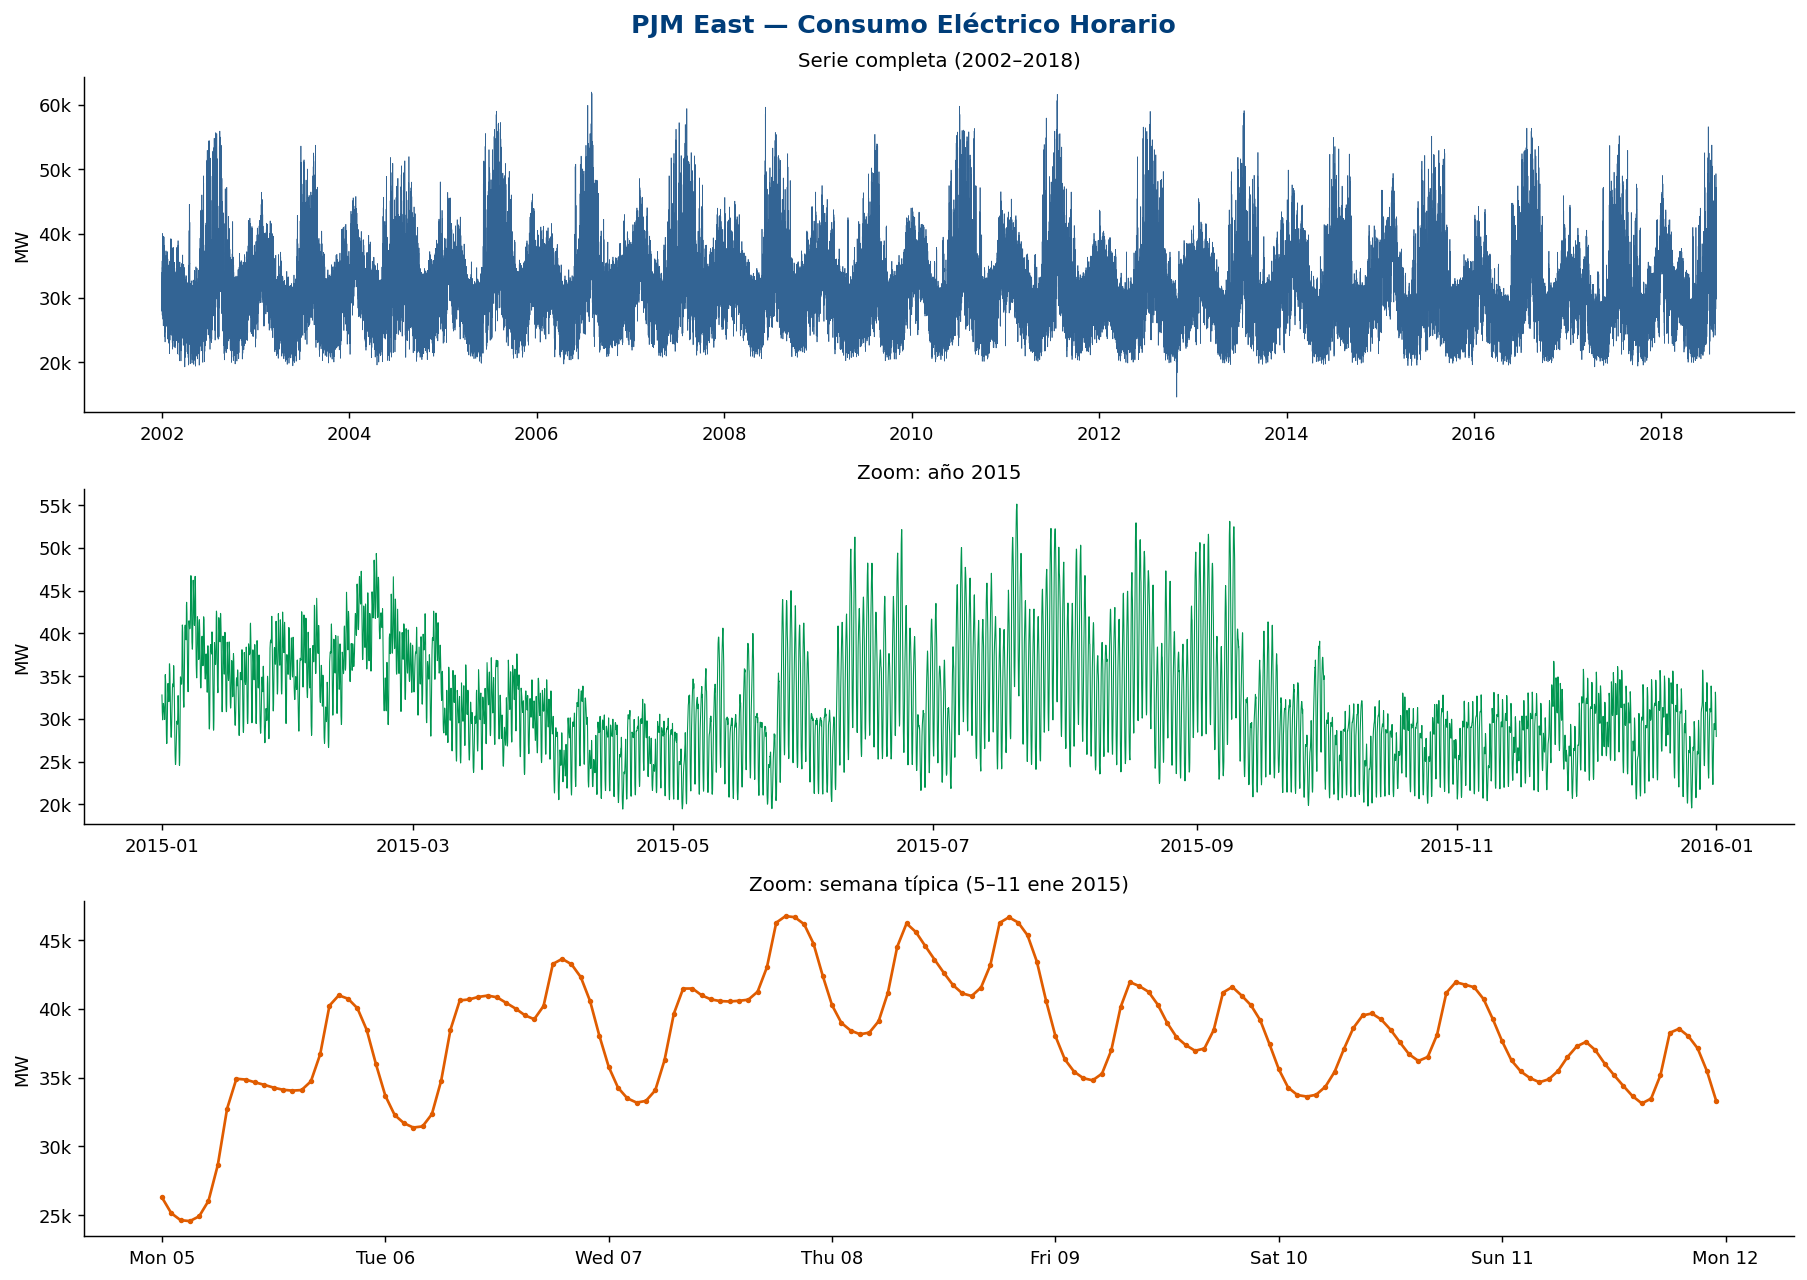

💾 Figura guardada: fig01_serie_temporal.png

✅ Features temporales creadas


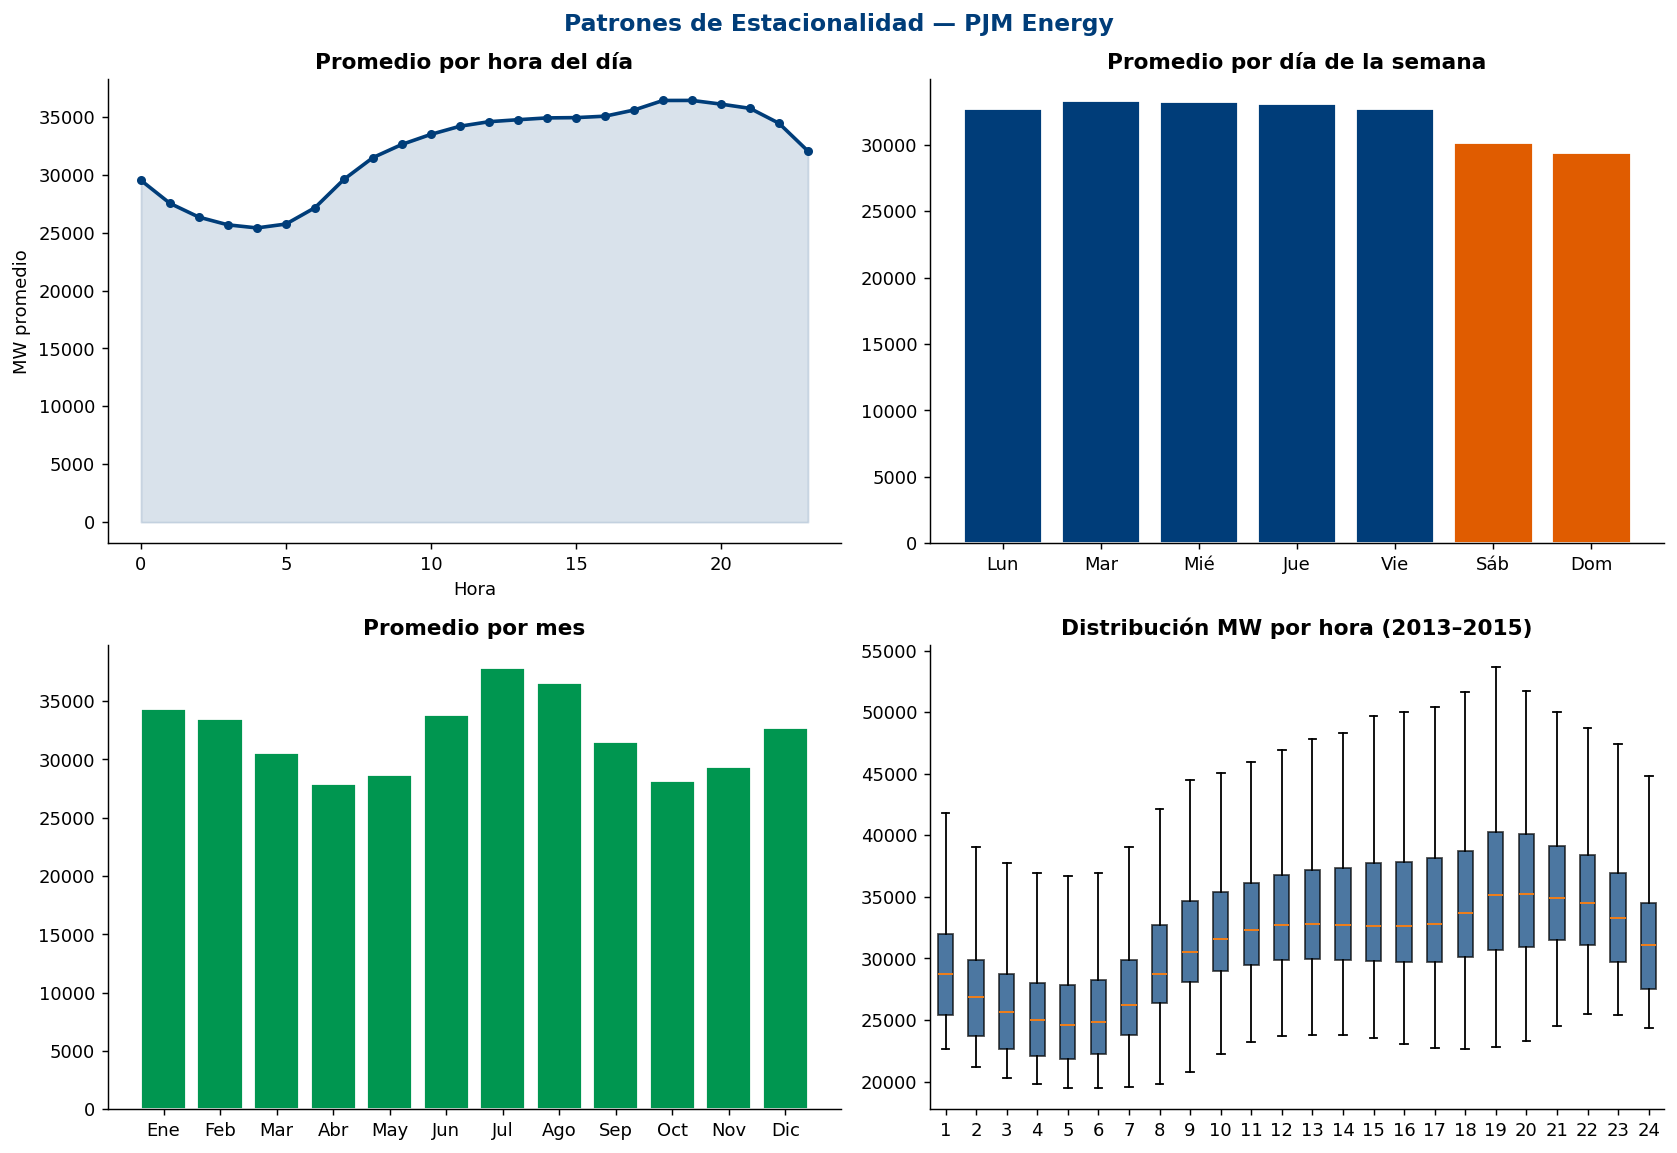

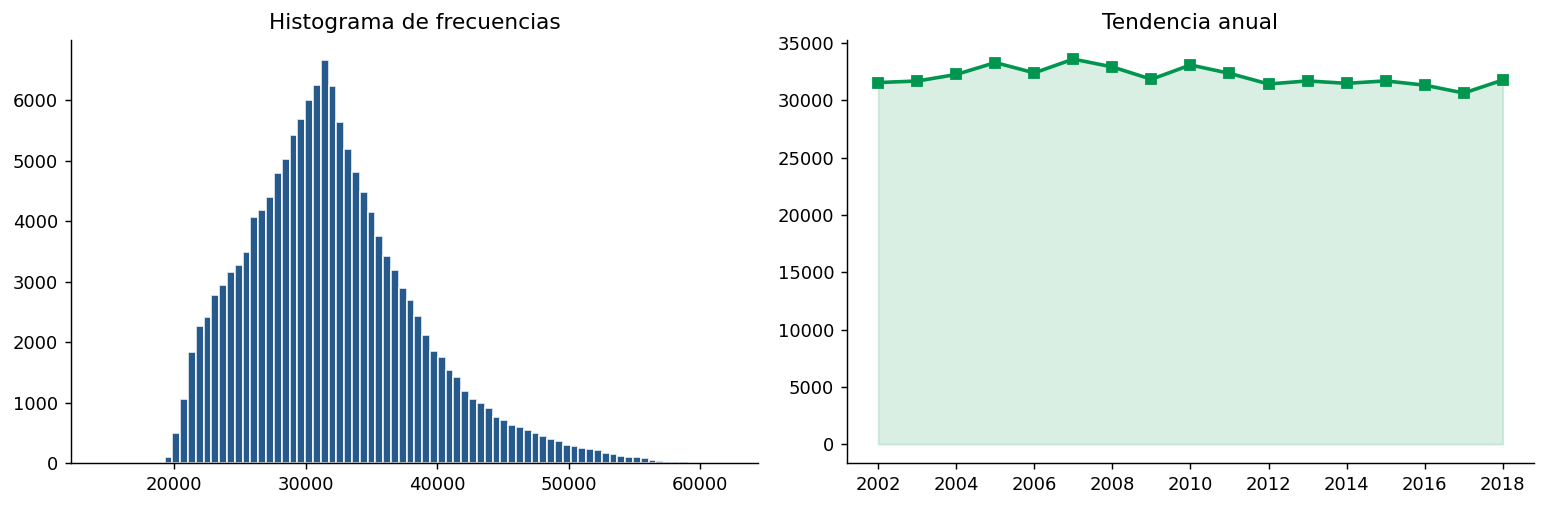


📊 Correlaciones:
hour          0.486303
month        -0.044522
quarter      -0.045276
dayofweek    -0.183058
is_weekend   -0.224173
Name: MW, dtype: float64


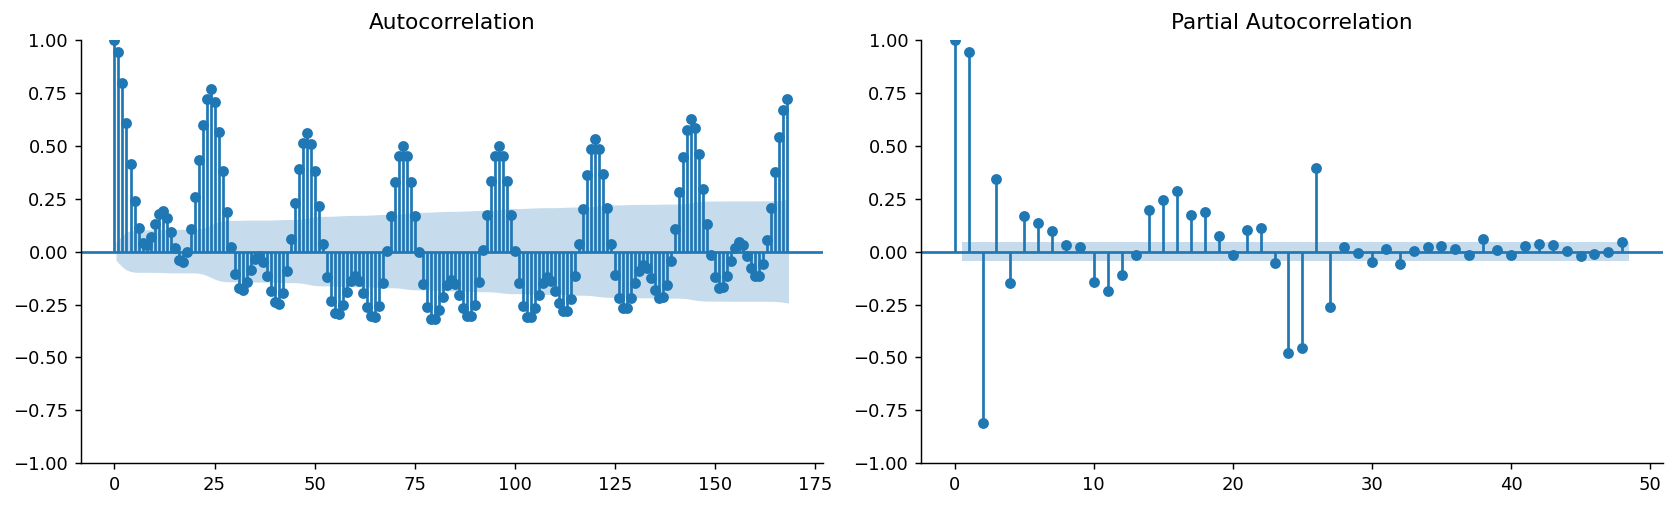


🧪 Test ADF
Estadístico: -19.8813
p-valor: 0.000000
✅ Serie estacionaria

🚨 Outliers detectados: 27

🔧 Iniciando preprocesamiento...
Huecos detectados: 30



📦 Split temporal
Train: 113,951
Val: 8,760
Test: 22,681



✅ Archivos guardados en data/processed/

RESUMEN DEL EDA
Registros: 145,392
Rango temporal: 2002–2018
Media MW: 32,079
Mínimo MW: 14,544
Máximo MW: 62,009
Outliers: 27
Huecos imputados: 30

✅ EDA completo
➡️ Continúa con 02_preprocessing.ipynb


In [4]:
# 📊 Notebook 01 — Análisis Exploratorio de Datos (EDA)
# EnergyForecast · IA EAFIT 2026-1

# ── Instalación de dependencias (solo en Colab) ──────────────────────────────
import subprocess
import sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'statsmodels']:
    install(pkg)

print('✅ Dependencias instaladas')


# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import os

warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

EAFIT_BLUE = '#003d79'
EAFIT_GREEN = '#009650'

print('✅ Imports OK')


# ── Crear carpetas necesarias ────────────────────────────────────────────────
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

print('✅ Carpetas verificadas')


# ── Carga del dataset ────────────────────────────────────────────────────────
# Coloca el archivo en:
# data/raw/PJME_hourly.csv

DATA_PATH = 'data/raw/PJME_hourly.csv'

try:
    df = pd.read_csv(DATA_PATH)
    print('✅ Dataset cargado desde data/raw/')
except FileNotFoundError:
    try:
        df = pd.read_csv('PJME_hourly.csv')
        print('✅ Dataset cargado desde carpeta raíz')
    except FileNotFoundError:
        raise FileNotFoundError(
            '❌ No se encontró el archivo PJME_hourly.csv.\n'
            'Colócalo en data/raw/PJME_hourly.csv'
        )

# Parseo de fechas
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Índice temporal
df = df.set_index('Datetime').sort_index()

# Renombrar columna
df.columns = ['MW']

print(f'\n📦 Shape: {df.shape}')
print(f'📅 Rango temporal: {df.index.min()} → {df.index.max()}')
print(f'📈 Años cubiertos: {df.index.year.nunique()}')
print(df.head())


# ── Estadísticas descriptivas ────────────────────────────────────────────────
desc = df.describe()

print('\n📋 Estadísticas descriptivas:')
print(desc.round(2))

# Valores nulos
nulls = df.isnull().sum()

print(f'\n🔍 Valores nulos: {nulls.values[0]}')

# Duplicados
dups = df.index.duplicated().sum()

print(f'🔍 Timestamps duplicados: {dups}')


# ── Serie temporal completa ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

fig.suptitle(
    'PJM East — Consumo Eléctrico Horario',
    fontsize=14,
    fontweight='bold',
    color=EAFIT_BLUE
)

# Serie completa
axes[0].plot(
    df.index,
    df['MW'],
    color=EAFIT_BLUE,
    linewidth=0.4,
    alpha=0.8
)

axes[0].set_title('Serie completa (2002–2018)', fontsize=11)
axes[0].set_ylabel('MW')

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')
)

# Zoom año 2015
df_2015 = df.loc['2015']

axes[1].plot(
    df_2015.index,
    df_2015['MW'],
    color=EAFIT_GREEN,
    linewidth=0.6
)

axes[1].set_title('Zoom: año 2015', fontsize=11)
axes[1].set_ylabel('MW')

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')
)

# Zoom semana
df_week = df.loc['2015-01-05':'2015-01-11']

axes[2].plot(
    df_week.index,
    df_week['MW'],
    color='#e05c00',
    linewidth=1.5,
    marker='o',
    markersize=2
)

axes[2].set_title('Zoom: semana típica (5–11 ene 2015)', fontsize=11)
axes[2].set_ylabel('MW')

axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')
)

axes[2].xaxis.set_major_formatter(
    mdates.DateFormatter('%a %d')
)

plt.tight_layout()

plt.savefig(
    'data/processed/fig01_serie_temporal.png',
    bbox_inches='tight'
)

plt.show()

print('💾 Figura guardada: fig01_serie_temporal.png')


# ── Ingeniería de características temporales ─────────────────────────────────
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year
df['dayofyear'] = df.index.dayofyear
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

print('\n✅ Features temporales creadas')


# ── Patrones de estacionalidad ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

fig.suptitle(
    'Patrones de Estacionalidad — PJM Energy',
    fontsize=13,
    fontweight='bold',
    color=EAFIT_BLUE
)

# Por hora
hourly = df.groupby('hour')['MW'].mean()

axes[0,0].plot(
    hourly.index,
    hourly.values,
    color=EAFIT_BLUE,
    linewidth=2,
    marker='o',
    markersize=4
)

axes[0,0].fill_between(
    hourly.index,
    hourly.values,
    alpha=0.15,
    color=EAFIT_BLUE
)

axes[0,0].set_title('Promedio por hora del día', fontweight='bold')
axes[0,0].set_xlabel('Hora')
axes[0,0].set_ylabel('MW promedio')

# Por día
day_names = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

weekly = df.groupby('dayofweek')['MW'].mean()

colors = [EAFIT_BLUE]*5 + ['#e05c00']*2

axes[0,1].bar(
    day_names,
    weekly.values,
    color=colors,
    edgecolor='white'
)

axes[0,1].set_title('Promedio por día de la semana', fontweight='bold')

# Por mes
month_names = [
    'Ene','Feb','Mar','Abr','May','Jun',
    'Jul','Ago','Sep','Oct','Nov','Dic'
]

monthly = df.groupby('month')['MW'].mean()

axes[1,0].bar(
    month_names,
    monthly.values,
    color=EAFIT_GREEN,
    edgecolor='white'
)

axes[1,0].set_title('Promedio por mes', fontweight='bold')

# Boxplot
df_sample = df[df['year'].isin([2013, 2014, 2015])]

hour_data = [
    df_sample[df_sample['hour'] == h]['MW'].values
    for h in range(24)
]

bp = axes[1,1].boxplot(
    hour_data,
    patch_artist=True,
    showfliers=False
)

for patch in bp['boxes']:
    patch.set_facecolor(EAFIT_BLUE)
    patch.set_alpha(0.7)

axes[1,1].set_title(
    'Distribución MW por hora (2013–2015)',
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'data/processed/fig02_estacionalidad.png',
    bbox_inches='tight'
)

plt.show()


# ── Distribución de MW ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(
    df['MW'],
    bins=80,
    color=EAFIT_BLUE,
    edgecolor='white',
    alpha=0.85
)

axes[0].set_title('Histograma de frecuencias')

# Tendencia anual
yearly = df.groupby('year')['MW'].mean()

axes[1].plot(
    yearly.index,
    yearly.values,
    color=EAFIT_GREEN,
    linewidth=2,
    marker='s'
)

axes[1].fill_between(
    yearly.index,
    yearly.values,
    alpha=0.15,
    color=EAFIT_GREEN
)

axes[1].set_title('Tendencia anual')

plt.tight_layout()

plt.savefig(
    'data/processed/fig03_distribucion.png',
    bbox_inches='tight'
)

plt.show()


# ── Correlaciones ────────────────────────────────────────────────────────────
corr_features = [
    'hour',
    'dayofweek',
    'month',
    'quarter',
    'is_weekend'
]

corr_vals = (
    df[corr_features + ['MW']]
    .corr()['MW']
    .drop('MW')
)

print('\n📊 Correlaciones:')
print(corr_vals.sort_values(ascending=False))


# ── ACF y PACF ───────────────────────────────────────────────────────────────
df_acf = df['MW'].iloc[:2000]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(df_acf, lags=168, ax=axes[0])
plot_pacf(df_acf, lags=48, ax=axes[1])

plt.tight_layout()

plt.savefig(
    'data/processed/fig05_acf_pacf.png',
    bbox_inches='tight'
)

plt.show()


# ── Test ADF ─────────────────────────────────────────────────────────────────
adf_result = adfuller(df['MW'].dropna())

print('\n🧪 Test ADF')
print(f'Estadístico: {adf_result[0]:.4f}')
print(f'p-valor: {adf_result[1]:.6f}')

if adf_result[1] < 0.05:
    print('✅ Serie estacionaria')
else:
    print('⚠️ Serie NO estacionaria')


# ── Detección de outliers ────────────────────────────────────────────────────
Q1 = df['MW'].quantile(0.25)
Q3 = df['MW'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

outliers = df[
    (df['MW'] < lower) |
    (df['MW'] > upper)
]

print(f'\n🚨 Outliers detectados: {len(outliers)}')


# ── Preprocesamiento final ───────────────────────────────────────────────────
print('\n🔧 Iniciando preprocesamiento...')

# Índice continuo horario
full_idx = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='h'
)

# Eliminar timestamps duplicados antes de reindex
df = df[~df.index.duplicated(keep='first')]

df_clean = df[['MW']].reindex(full_idx)

# Huecos
gaps = df_clean['MW'].isnull().sum()

print(f'Huecos detectados: {gaps}')

# Interpolación
df_clean['MW'] = df_clean['MW'].interpolate(method='time')

# Nombre índice
df_clean.index.name = 'Datetime'

# Features temporales
df_clean['hour'] = df_clean.index.hour
df_clean['dayofweek'] = df_clean.index.dayofweek
df_clean['month'] = df_clean.index.month
df_clean['quarter'] = df_clean.index.quarter
df_clean['year'] = df_clean.index.year
df_clean['dayofyear'] = df_clean.index.dayofyear
df_clean['is_weekend'] = (
    df_clean['dayofweek'] >= 5
).astype(int)

# Split temporal
df_train = df_clean.loc[:'2014']
df_val = df_clean.loc['2015':'2015']
df_test = df_clean.loc['2016':]

print('\n📦 Split temporal')
print(f'Train: {len(df_train):,}')
print(f'Val: {len(df_val):,}')
print(f'Test: {len(df_test):,}')

# Guardar archivos
df_clean.to_csv('data/processed/PJME_clean.csv')
df_train.to_csv('data/processed/train.csv')
df_val.to_csv('data/processed/val.csv')
df_test.to_csv('data/processed/test.csv')

print('\n✅ Archivos guardados en data/processed/')


# ── Resumen final ────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('RESUMEN DEL EDA')
print('='*55)

print(f'Registros: {len(df_clean):,}')
print(f'Rango temporal: {df_clean.index.min().year}–{df_clean.index.max().year}')
print(f'Media MW: {df_clean["MW"].mean():,.0f}')
print(f'Mínimo MW: {df_clean["MW"].min():,.0f}')
print(f'Máximo MW: {df_clean["MW"].max():,.0f}')
print(f'Outliers: {len(outliers)}')
print(f'Huecos imputados: {gaps}')

print('\n✅ EDA completo')
print('➡️ Continúa con 02_preprocessing.ipynb')

In [5]:
# ── Estadísticas descriptivas ────────────────────────────────────────────────
desc = df.describe()
print('\n📋 Estadísticas descriptivas:')
print(desc.round(2))

# Valores nulos
nulls = df.isnull().sum()
print(f'\n🔍 Valores nulos: {nulls.values[0]}')

# Duplicados
dups = df.index.duplicated().sum()
print(f'🔍 Timestamps duplicados: {dups}')


📋 Estadísticas descriptivas:


              MW       hour  dayofweek      month    quarter       year  \
count  145362.00  145362.00   145362.0  145362.00  145362.00  145362.00   
mean    32080.51      11.50        3.0       6.44       2.48    2009.80   
std      6463.87       6.92        2.0       3.44       1.11       4.79   
min     14544.00       0.00        0.0       1.00       1.00    2002.00   
25%     27573.00       6.00        1.0       3.00       1.00    2006.00   
50%     31421.00      12.00        3.0       6.00       2.00    2010.00   
75%     35650.00      18.00        5.0       9.00       3.00    2014.00   
max     62009.00      23.00        6.0      12.00       4.00    2018.00   

       dayofyear  is_weekend  
count  145362.00   145362.00  
mean      180.46        0.29  
std       105.14        0.45  
min         1.00        0.00  
25%        90.00        0.00  
50%       179.00        0.00  
75%       271.00        1.00  
max       366.00        1.00  

🔍 Valores nulos: 0
🔍 Timestamps duplicados: 

## 2. Visualización de la serie temporal

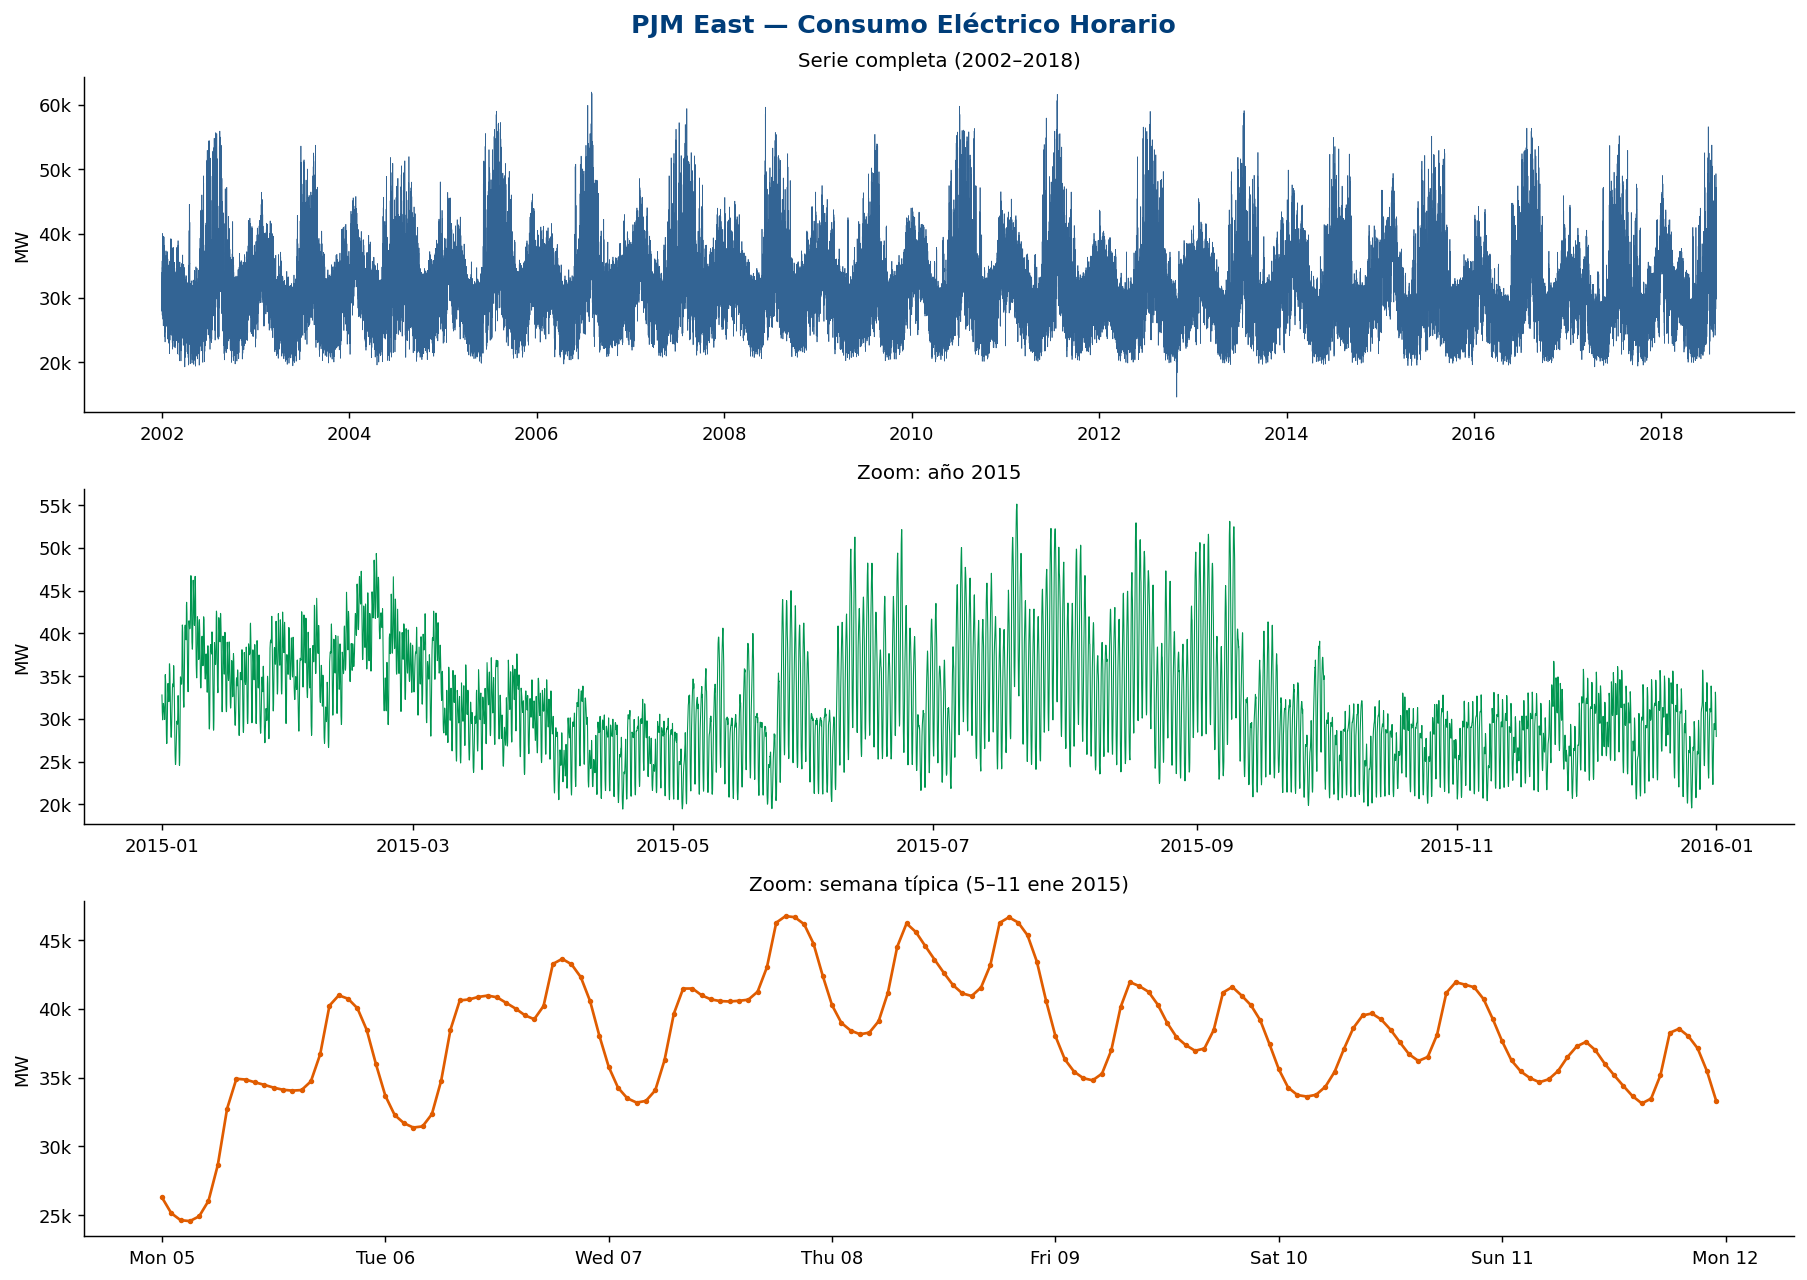

💾 Figura guardada: fig01_serie_temporal.png


In [6]:
# ── Serie temporal completa ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('PJM East — Consumo Eléctrico Horario', fontsize=14, fontweight='bold', color=EAFIT_BLUE)

# Serie completa
axes[0].plot(df.index, df['MW'], color=EAFIT_BLUE, linewidth=0.4, alpha=0.8)
axes[0].set_title('Serie completa (2002–2018)', fontsize=11)
axes[0].set_ylabel('MW')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Zoom: un año
df_2015 = df.loc['2015']
axes[1].plot(df_2015.index, df_2015['MW'], color=EAFIT_GREEN, linewidth=0.6)
axes[1].set_title('Zoom: año 2015', fontsize=11)
axes[1].set_ylabel('MW')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Zoom: una semana
df_week = df.loc['2015-01-05':'2015-01-11']
axes[2].plot(df_week.index, df_week['MW'], color='#e05c00', linewidth=1.5, marker='o', markersize=2)
axes[2].set_title('Zoom: semana típica (5–11 ene 2015)', fontsize=11)
axes[2].set_ylabel('MW')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))

plt.tight_layout()
plt.savefig('data/processed/fig01_serie_temporal.png', bbox_inches='tight')
plt.show()
print('💾 Figura guardada: fig01_serie_temporal.png')

## 3. Análisis de distribución y estacionalidad

In [7]:
# ── Ingeniería de características temporales ─────────────────────────────────
df['hour']       = df.index.hour
df['dayofweek']  = df.index.dayofweek   # 0=lunes, 6=domingo
df['month']      = df.index.month
df['quarter']    = df.index.quarter
df['year']       = df.index.year
df['dayofyear']  = df.index.dayofyear
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

print('✅ Features temporales creadas:', [c for c in df.columns if c != 'MW'])

✅ Features temporales creadas: ['hour', 'dayofweek', 'month', 'quarter', 'year', 'dayofyear', 'is_weekend']


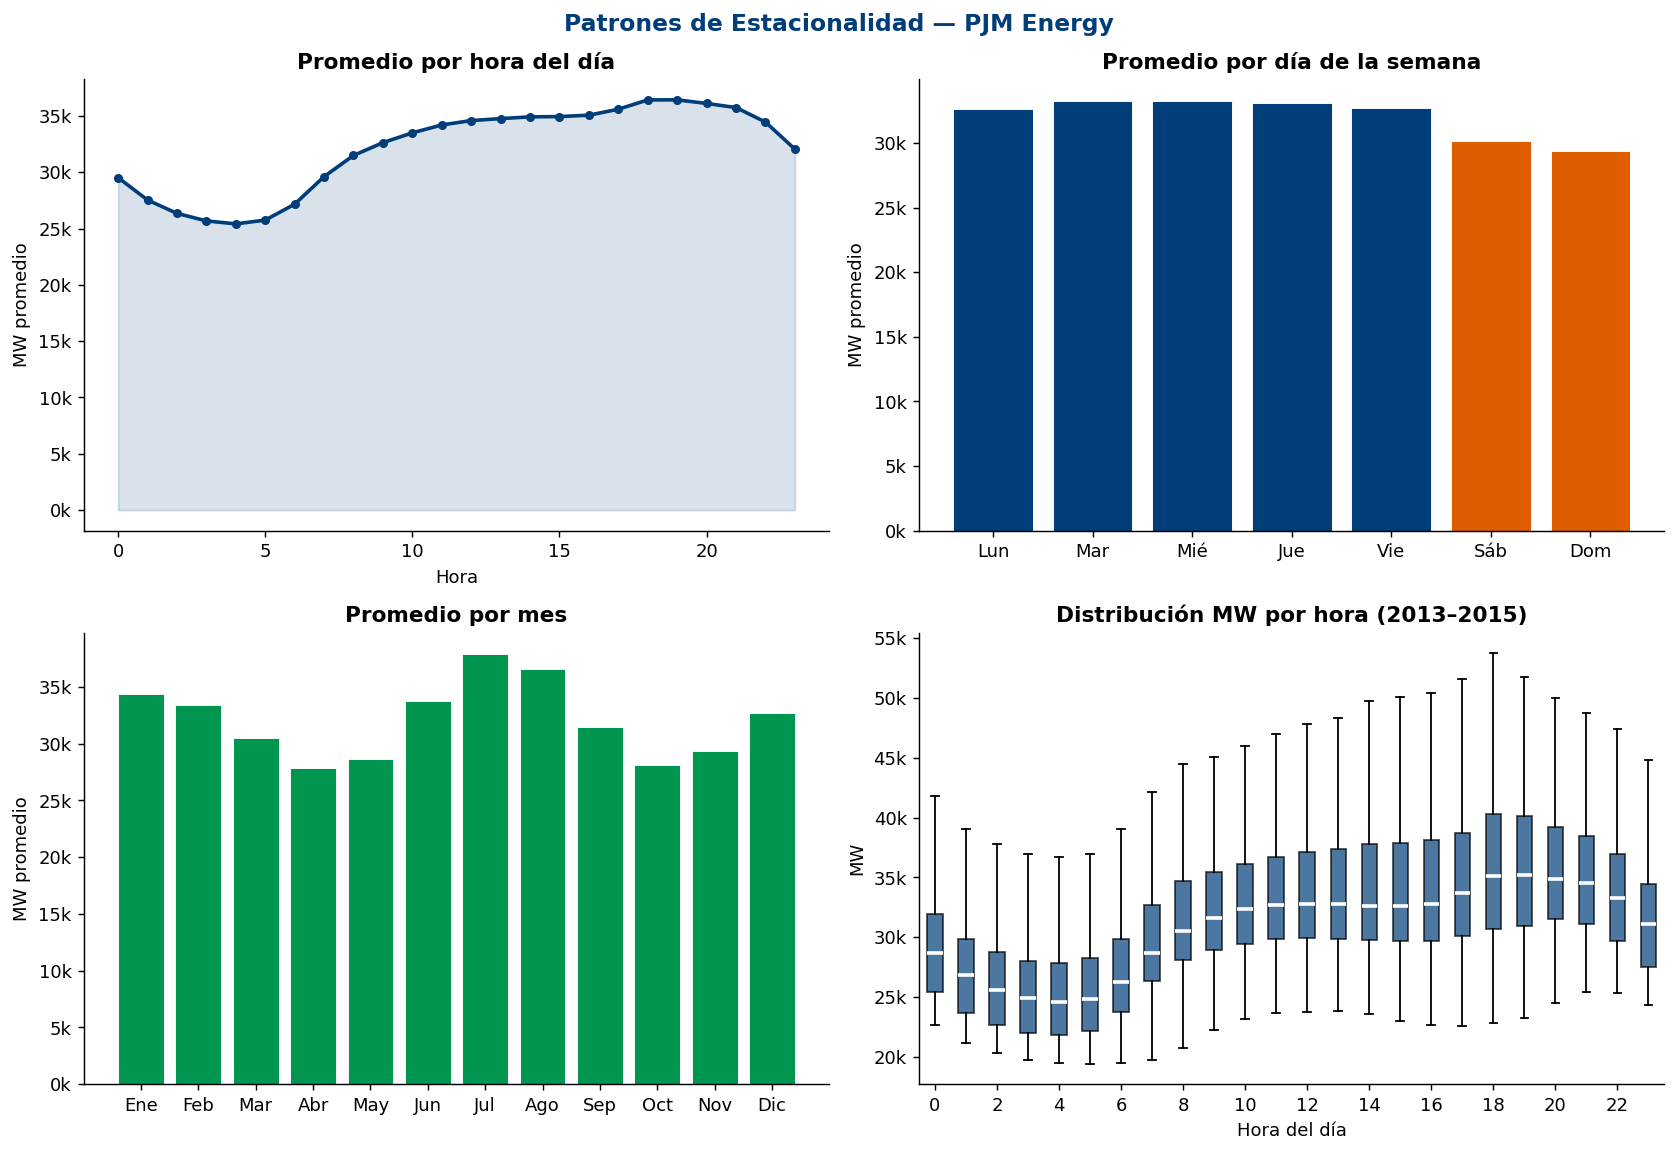

In [8]:
# ── Patrones de estacionalidad ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Patrones de Estacionalidad — PJM Energy', fontsize=13, fontweight='bold', color=EAFIT_BLUE)

# Por hora del día
hourly = df.groupby('hour')['MW'].mean()
axes[0,0].plot(hourly.index, hourly.values, color=EAFIT_BLUE, linewidth=2, marker='o', markersize=4)
axes[0,0].fill_between(hourly.index, hourly.values, alpha=0.15, color=EAFIT_BLUE)
axes[0,0].set_title('Promedio por hora del día', fontweight='bold')
axes[0,0].set_xlabel('Hora')
axes[0,0].set_ylabel('MW promedio')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Por día de la semana
day_names = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
weekly = df.groupby('dayofweek')['MW'].mean()
colors = [EAFIT_BLUE]*5 + ['#e05c00']*2
axes[0,1].bar(day_names, weekly.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0,1].set_title('Promedio por día de la semana', fontweight='bold')
axes[0,1].set_ylabel('MW promedio')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Por mes
month_names = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
monthly = df.groupby('month')['MW'].mean()
axes[1,0].bar(month_names, monthly.values, color=EAFIT_GREEN, edgecolor='white', linewidth=0.5)
axes[1,0].set_title('Promedio por mes', fontweight='bold')
axes[1,0].set_ylabel('MW promedio')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Boxplot por hora (distribución completa)
df_sample = df[df['year'].isin([2013,2014,2015])]
hour_data = [df_sample[df_sample['hour']==h]['MW'].values for h in range(24)]
bp = axes[1,1].boxplot(hour_data, patch_artist=True, showfliers=False,
                        medianprops=dict(color='white', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor(EAFIT_BLUE)
    patch.set_alpha(0.7)
axes[1,1].set_title('Distribución MW por hora (2013–2015)', fontweight='bold')
axes[1,1].set_xlabel('Hora del día')
axes[1,1].set_ylabel('MW')
axes[1,1].set_xticks(range(1,25,2))
axes[1,1].set_xticklabels(range(0,24,2))
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('data/processed/fig02_estacionalidad.png', bbox_inches='tight')
plt.show()

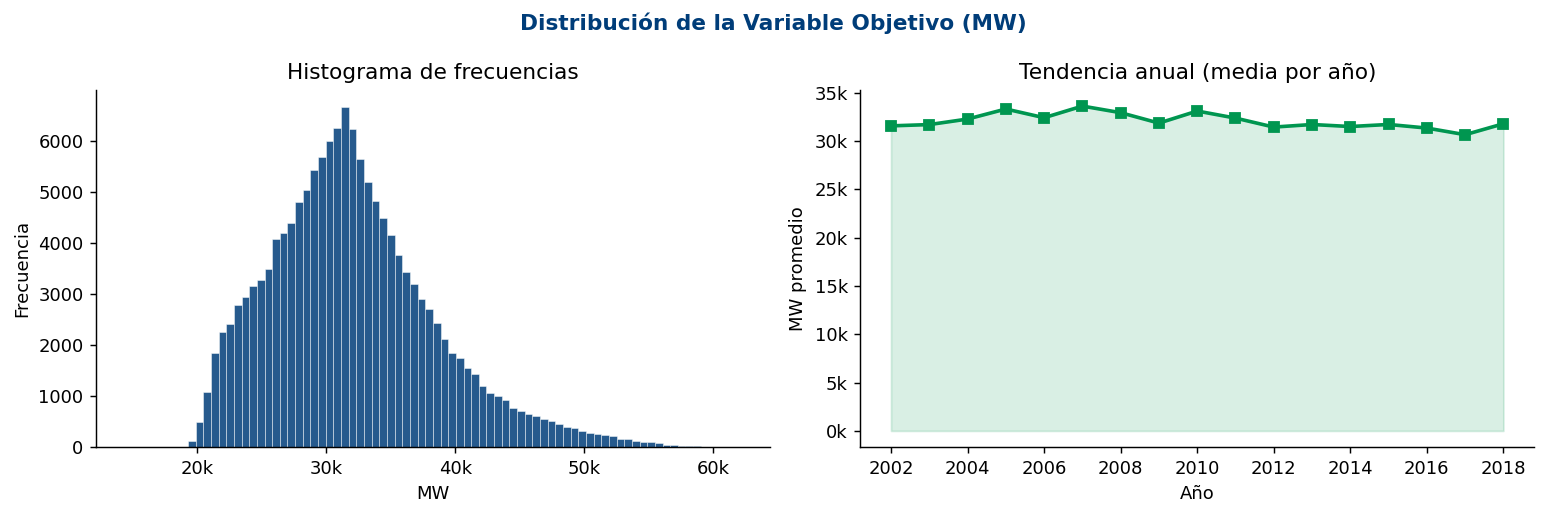

Media: 32,081 MW
Mediana: 31,421 MW
Desv. estándar: 6,464 MW
Mín: 14,544 MW | Máx: 62,009 MW


In [9]:
# ── Distribución de la variable objetivo ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribución de la Variable Objetivo (MW)', fontsize=12, fontweight='bold', color=EAFIT_BLUE)

axes[0].hist(df['MW'], bins=80, color=EAFIT_BLUE, edgecolor='white', linewidth=0.3, alpha=0.85)
axes[0].set_title('Histograma de frecuencias')
axes[0].set_xlabel('MW')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Tendencia anual
yearly = df.groupby('year')['MW'].mean()
axes[1].plot(yearly.index, yearly.values, color=EAFIT_GREEN, linewidth=2, marker='s', markersize=6)
axes[1].fill_between(yearly.index, yearly.values, alpha=0.15, color=EAFIT_GREEN)
axes[1].set_title('Tendencia anual (media por año)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('MW promedio')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('data/processed/fig03_distribucion.png', bbox_inches='tight')
plt.show()

print(f'Media: {df["MW"].mean():,.0f} MW')
print(f'Mediana: {df["MW"].median():,.0f} MW')
print(f'Desv. estándar: {df["MW"].std():,.0f} MW')
print(f'Mín: {df["MW"].min():,.0f} MW | Máx: {df["MW"].max():,.0f} MW')

## 4. Correlaciones y lag features

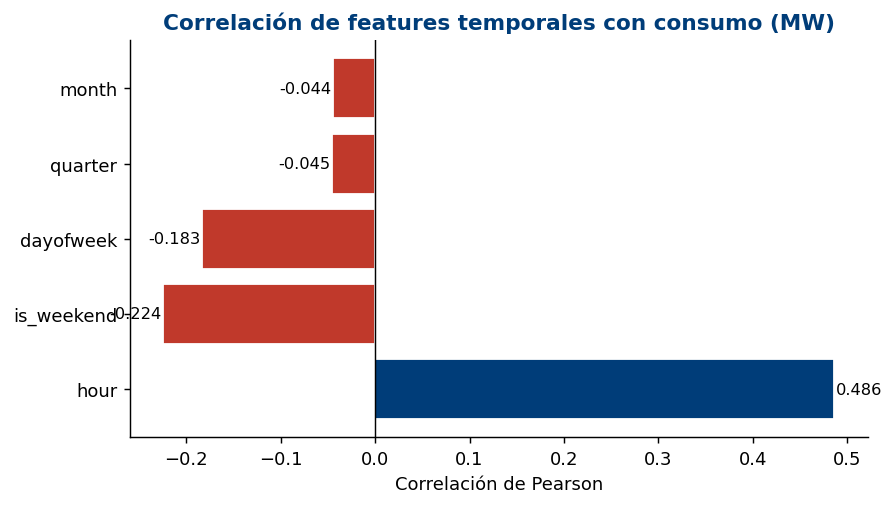

In [10]:
# ── Correlación de features temporales con MW ─────────────────────────────────
corr_features = ['hour', 'dayofweek', 'month', 'quarter', 'is_weekend']
corr_vals = df[corr_features + ['MW']].corr()['MW'].drop('MW').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [EAFIT_BLUE if v > 0 else '#c0392b' for v in corr_vals.values]
bars = ax.barh(corr_vals.index, corr_vals.values, color=colors, edgecolor='white')
ax.set_title('Correlación de features temporales con consumo (MW)', fontweight='bold', color=EAFIT_BLUE)
ax.set_xlabel('Correlación de Pearson')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_vals.values):
    ax.text(val + 0.002*np.sign(val), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('data/processed/fig04_correlaciones.png', bbox_inches='tight')
plt.show()

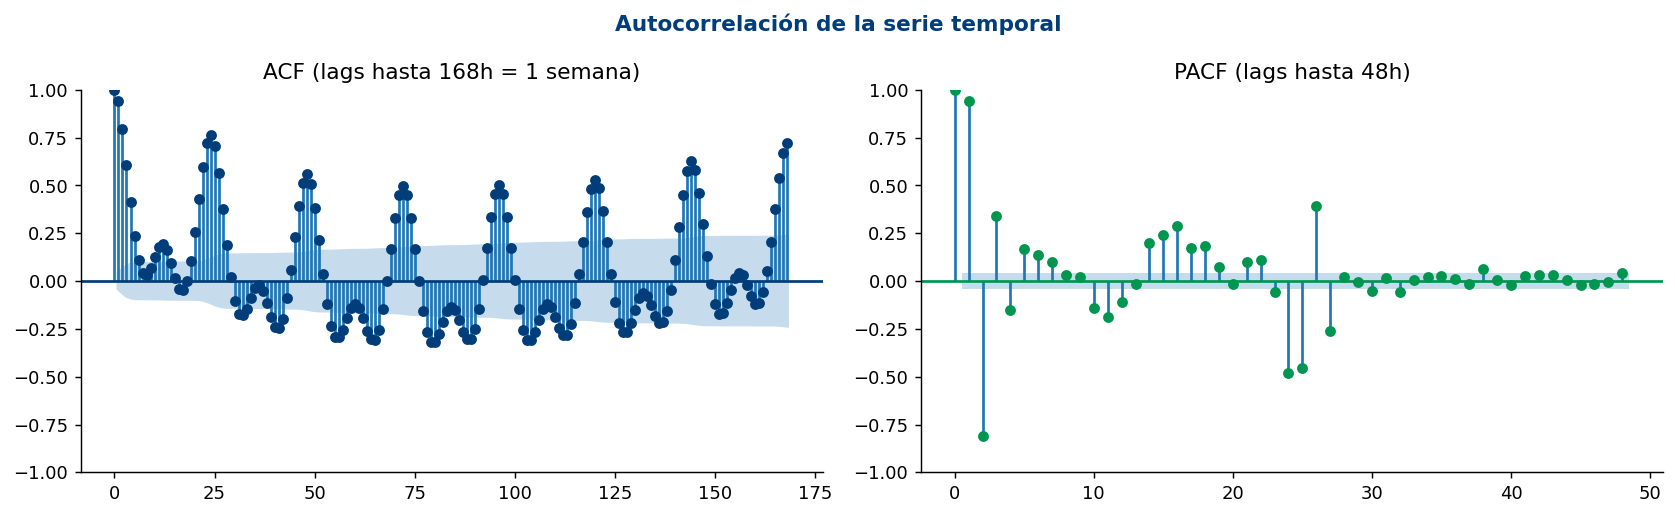


📝 Interpretación ACF:
  - Pico fuerte en lag 24 → estacionalidad diaria
  - Pico fuerte en lag 168 → estacionalidad semanal
  - Decaimiento lento → serie con tendencia (no estacionaria)


In [11]:
# ── ACF y PACF ───────────────────────────────────────────────────────────────
# Usamos muestra para no saturar el plot (primeras 2000 obs)
df_acf = df['MW'].iloc[:2000]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Autocorrelación de la serie temporal', fontsize=12, fontweight='bold', color=EAFIT_BLUE)
plot_acf(df_acf, lags=168, ax=axes[0], color=EAFIT_BLUE, title='ACF (lags hasta 168h = 1 semana)')
plot_pacf(df_acf, lags=48, ax=axes[1], color=EAFIT_GREEN, title='PACF (lags hasta 48h)')
plt.tight_layout()
plt.savefig('data/processed/fig05_acf_pacf.png', bbox_inches='tight')
plt.show()

print('\n📝 Interpretación ACF:')
print('  - Pico fuerte en lag 24 → estacionalidad diaria')
print('  - Pico fuerte en lag 168 → estacionalidad semanal')
print('  - Decaimiento lento → serie con tendencia (no estacionaria)')

In [12]:
# ── Test de estacionariedad (ADF) ─────────────────────────────────────────────
adf_result = adfuller(df['MW'].dropna(), autolag='AIC')
print('\n🧪 Test Augmented Dickey-Fuller:')
print(f'  Estadístico ADF: {adf_result[0]:.4f}')
print(f'  p-valor:         {adf_result[1]:.6f}')
print(f'  Valores críticos:')
for k, v in adf_result[4].items():
    print(f'    {k}: {v:.4f}')
if adf_result[1] < 0.05:
    print('\n✅ La serie ES estacionaria (p < 0.05)')
else:
    print('\n⚠️  La serie NO es estacionaria (p >= 0.05) → se necesita diferenciación')


🧪 Test Augmented Dickey-Fuller:
  Estadístico ADF: -19.8855
  p-valor:         0.000000
  Valores críticos:
    1%: -3.4304
    5%: -2.8616
    10%: -2.5668

✅ La serie ES estacionaria (p < 0.05)


## 5. Detección de anomalías y valores atípicos

In [13]:
# ── Detección de outliers con IQR ─────────────────────────────────────────────
Q1 = df['MW'].quantile(0.25)
Q3 = df['MW'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

outliers = df[(df['MW'] < lower) | (df['MW'] > upper)]
print(f'Límite inferior (Q1 - 3·IQR): {lower:,.0f} MW')
print(f'Límite superior (Q3 + 3·IQR): {upper:,.0f} MW')
print(f'Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% del dataset)')

if len(outliers) > 0:
    print('\nEjemplos de outliers:')
    print(outliers.head(10))

Límite inferior (Q1 - 3·IQR): 3,342 MW
Límite superior (Q3 + 3·IQR): 59,881 MW
Outliers detectados: 27 (0.02% del dataset)

Ejemplos de outliers:
                          MW  hour  dayofweek  month  quarter  year  \
Datetime                                                              
2006-07-18 17:00:00  59943.0    17          1      7        3  2006   
2006-08-01 14:00:00  60028.0    14          1      8        3  2006   
2006-08-01 15:00:00  61004.0    15          1      8        3  2006   
2006-08-01 16:00:00  61366.0    16          1      8        3  2006   
2006-08-01 17:00:00  61643.0    17          1      8        3  2006   
2006-08-01 18:00:00  61155.0    18          1      8        3  2006   
2006-08-01 19:00:00  60047.0    19          1      8        3  2006   
2006-08-02 14:00:00  61008.0    14          2      8        3  2006   
2006-08-02 15:00:00  61641.0    15          2      8        3  2006   
2006-08-02 16:00:00  61909.0    16          2      8        3  2006   

 

## 6. Preprocesamiento final y guardado

In [14]:
# ── Pipeline de preprocesamiento ──────────────────────────────────────────────
print('🔧 Iniciando preprocesamiento...')

# 1. Rellenar huecos en el índice temporal (asegurar continuidad horaria)
full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df_clean = df[['MW']].reindex(full_idx)
gaps = df_clean['MW'].isnull().sum()
print(f'   Huecos temporales detectados: {gaps}')

# 2. Imputación con interpolación lineal
df_clean['MW'] = df_clean['MW'].interpolate(method='time')
df_clean.index.name = 'Datetime'
print(f'   Valores nulos tras imputación: {df_clean["MW"].isnull().sum()}')

# 3. Re-agregar features temporales
df_clean['hour']       = df_clean.index.hour
df_clean['dayofweek']  = df_clean.index.dayofweek
df_clean['month']      = df_clean.index.month
df_clean['quarter']    = df_clean.index.quarter
df_clean['year']       = df_clean.index.year
df_clean['dayofyear']  = df_clean.index.dayofyear
df_clean['is_weekend'] = (df_clean['dayofweek'] >= 5).astype(int)

# 4. Split temporal (train/val/test)
# Train: 2002–2014 | Val: 2015 | Test: 2016–2018
df_train = df_clean[:'2014']
df_val   = df_clean['2015':'2015']
df_test  = df_clean['2016':]

print(f'\n📦 Split temporal:')
print(f'   Train: {len(df_train):,} registros ({df_train.index.min().date()} → {df_train.index.max().date()})')
print(f'   Val:   {len(df_val):,} registros ({df_val.index.min().date()} → {df_val.index.max().date()})')
print(f'   Test:  {len(df_test):,} registros ({df_test.index.min().date()} → {df_test.index.max().date()})')
print(f'\n   Proporción: {len(df_train)/len(df_clean)*100:.1f}% / {len(df_val)/len(df_clean)*100:.1f}% / {len(df_test)/len(df_clean)*100:.1f}%')

# 5. Guardar
import os
os.makedirs('data/processed', exist_ok=True)
df_clean.to_csv('data/processed/PJME_clean.csv')
df_train.to_csv('data/processed/train.csv')
df_val.to_csv('data/processed/val.csv')
df_test.to_csv('data/processed/test.csv')
print('\n✅ Archivos guardados en data/processed/')

🔧 Iniciando preprocesamiento...
   Huecos temporales detectados: 30
   Valores nulos tras imputación: 0

📦 Split temporal:
   Train: 113,951 registros (2002-01-01 → 2014-12-31)
   Val:   8,760 registros (2015-01-01 → 2015-12-31)
   Test:  22,681 registros (2016-01-01 → 2018-08-03)

   Proporción: 78.4% / 6.0% / 15.6%



✅ Archivos guardados en data/processed/


In [15]:
# ── Resumen final del EDA ──────────────────────────────────────────────────────
print('='*55)
print('  RESUMEN DEL EDA — PJM Energy Consumption')
print('='*55)
print(f'  Registros totales:  {len(df_clean):,}')
print(f'  Rango temporal:     {df_clean.index.min().year}–{df_clean.index.max().year}')
print(f'  Variable objetivo:  MW (continua, regresión)')
print(f'  Media:              {df_clean["MW"].mean():,.0f} MW')
print(f'  Rango:              {df_clean["MW"].min():,.0f} – {df_clean["MW"].max():,.0f} MW')
print(f'  Outliers (3·IQR):  {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
print(f'  Huecos imputados:   {gaps}')
print(f'  Features creadas:   hour, dayofweek, month, quarter,')
print(f'                      year, dayofyear, is_weekend')
print('='*55)
print('\n✅ EDA completo. Continúa con 02_preprocessing.ipynb')

  RESUMEN DEL EDA — PJM Energy Consumption
  Registros totales:  145,392
  Rango temporal:     2002–2018
  Variable objetivo:  MW (continua, regresión)
  Media:              32,079 MW
  Rango:              14,544 – 62,009 MW
  Outliers (3·IQR):  27 (0.02%)
  Huecos imputados:   30
  Features creadas:   hour, dayofweek, month, quarter,
                      year, dayofyear, is_weekend

✅ EDA completo. Continúa con 02_preprocessing.ipynb
